In [8]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt


def read_cnv(path):
    """Read a Sea-Bird .cnv file and return metadata + selected columns."""
    path = Path(path)
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()

    station = None
    start_time = None
    lat = None
    lon = None
    col_map = {}
    end_idx = None

    for i, line in enumerate(lines):
        if line.startswith("** Station:"):
            station = line.split(":", 1)[1].strip()
        elif line.startswith("# start_time ="):
            start_time = line.split("=", 1)[1].split("[")[0].strip()
        elif line.startswith("* NMEA Latitude ="):
            lat = line.split("=", 1)[1].strip()
        elif line.startswith("* NMEA Longitude ="):
            lon = line.split("=", 1)[1].strip()

        m = re.match(r"# name\s+(\d+)\s*=\s*([^:]+):", line)
        if m:
            col_map[m.group(2).strip()] = int(m.group(1))

        if line.strip() == "*END*":
            end_idx = i
            break

    if end_idx is None:
        raise ValueError(f"Could not find *END* in {path.name}")

    data = np.loadtxt(lines[end_idx + 1 :])
    if data.ndim == 1:
        data = data[np.newaxis, :]

    required = ["prDM", "t068C", "sal00", "sbeox0ML/L"]
    missing = [name for name in required if name not in col_map]
    if missing:
        raise ValueError(f"Missing required columns in {path.name}: {missing}")

    return {
        "file": path.name,
        "station": station,
        "start_time": start_time,
        "lat": lat,
        "lon": lon,
        "pressure_db": data[:, col_map["prDM"]],
        "temperature_c": data[:, col_map["t068C"]],
        "salinity_psu": data[:, col_map["sal00"]],
        "oxygen_ml_l": data[:, col_map["sbeox0ML/L"]],
    }


def plot_ctd_profile(file_name, base_path="."):
    """Plot one cast with a common depth axis and separate x-axes for each variable."""
    file_path = Path(base_path) / file_name
    cast = read_cnv(file_path)
    depth = cast["pressure_db"]

    fig, ax_oxy = plt.subplots(figsize=(9, 8))
    ax_tmp = ax_oxy.twiny()
    ax_sal = ax_oxy.twiny()

    ax_sal.spines["top"].set_position(("axes", 1.10))

    line_oxy, = ax_oxy.plot(cast["oxygen_ml_l"], depth, color="tab:blue", lw=1.8, label="Oxygen (mL/L)")
    line_tmp, = ax_tmp.plot(cast["temperature_c"], depth, color="tab:red", lw=1.8, label="Temperature (°C)")
    line_sal, = ax_sal.plot(cast["salinity_psu"], depth, color="tab:green", lw=1.8, label="Salinity (PSU)")

    ax_oxy.set_xlabel("Oxygen (mL/L)", color="tab:blue")
    ax_tmp.set_xlabel("Temperature (°C)", color="tab:red")
    ax_sal.set_xlabel("Salinity (PSU)", color="tab:green")

    ax_oxy.tick_params(axis="x", colors="tab:blue")
    ax_tmp.tick_params(axis="x", colors="tab:red")
    ax_sal.tick_params(axis="x", colors="tab:green")

    ax_oxy.set_ylabel("Depth (approx. m from pressure dbar)")
    ax_oxy.invert_yaxis()
    ax_oxy.grid(True, alpha=0.3)

    station_txt = cast["station"] if cast["station"] is not None else "Unknown"
    ax_oxy.set_title(f"CTD Profile | {cast['file']} | Station {station_txt}")

    lines = [line_oxy, line_tmp, line_sal]
    labels = [line.get_label() for line in lines]
    ax_oxy.legend(lines, labels, loc="lower center")

    fig.tight_layout()
    plt.show()

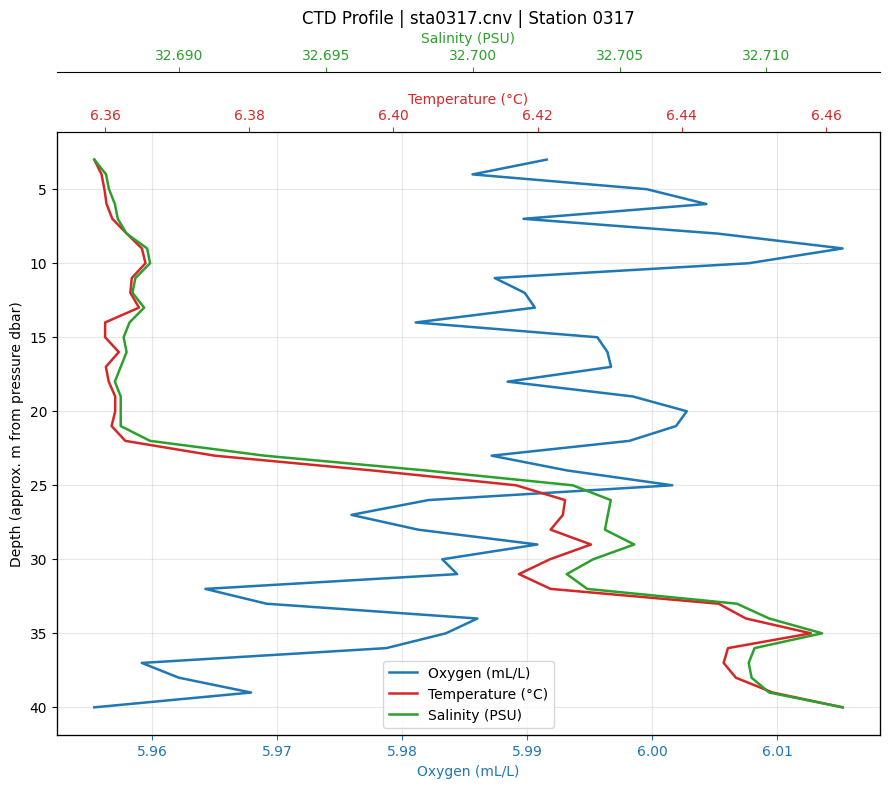

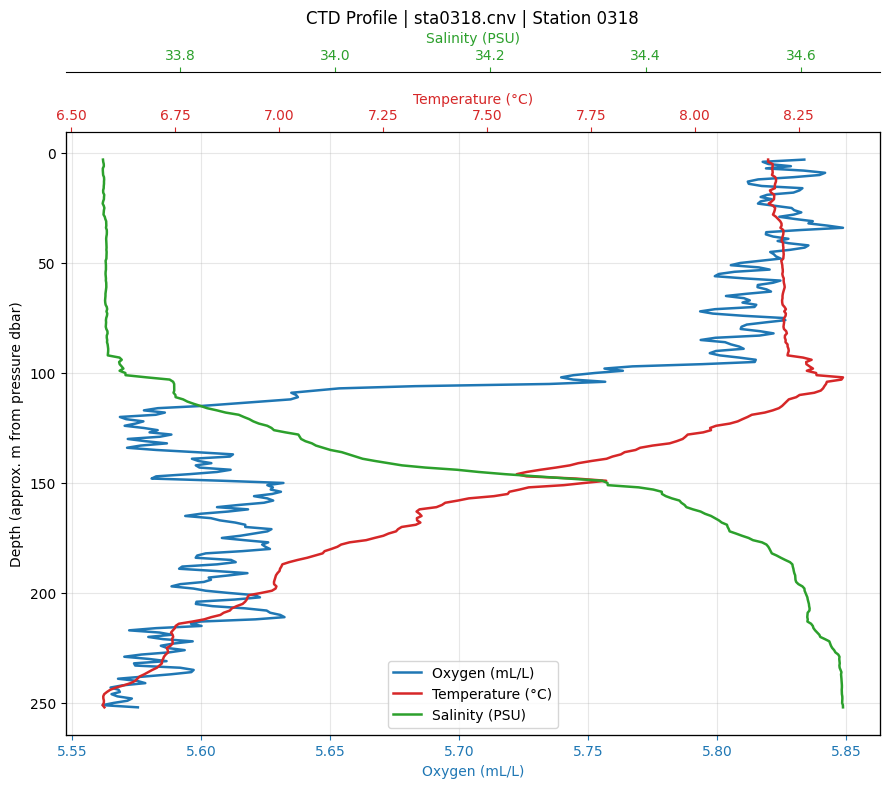

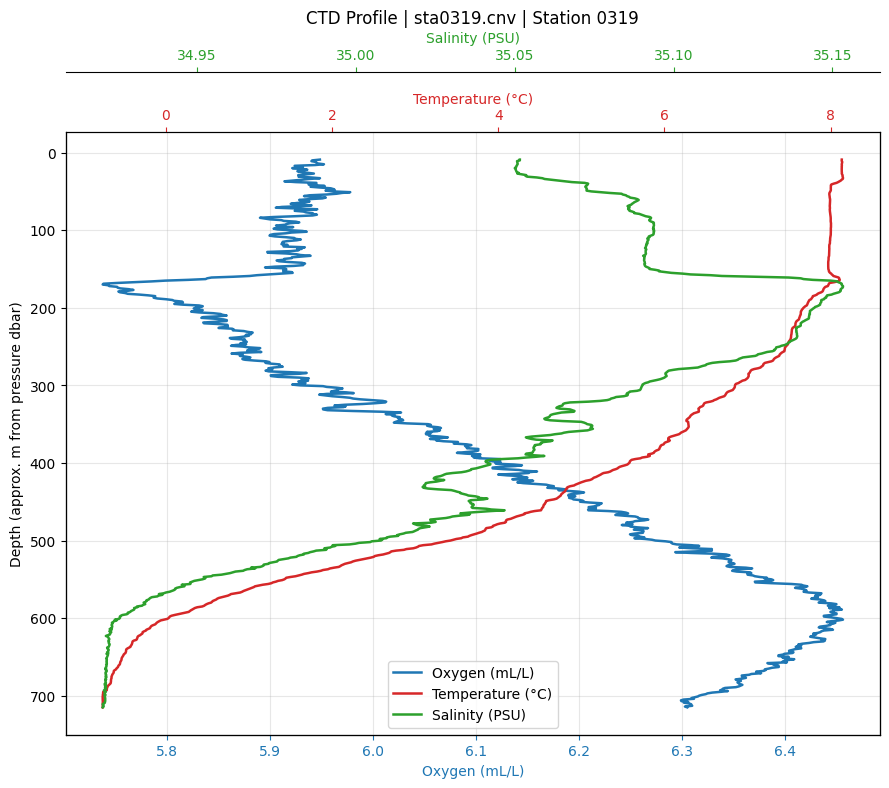

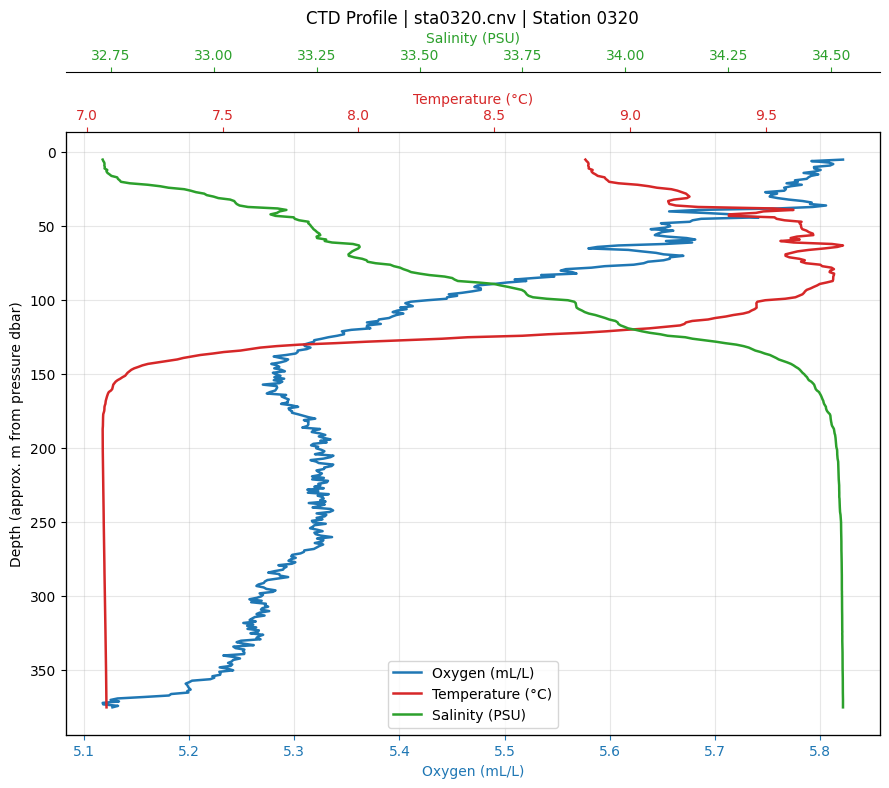

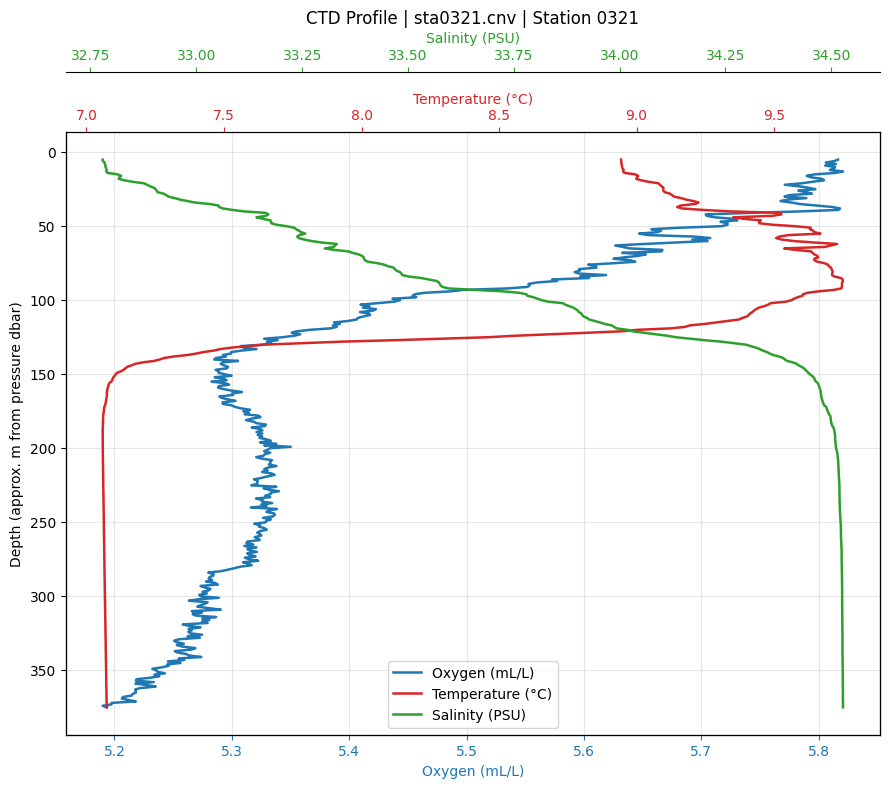

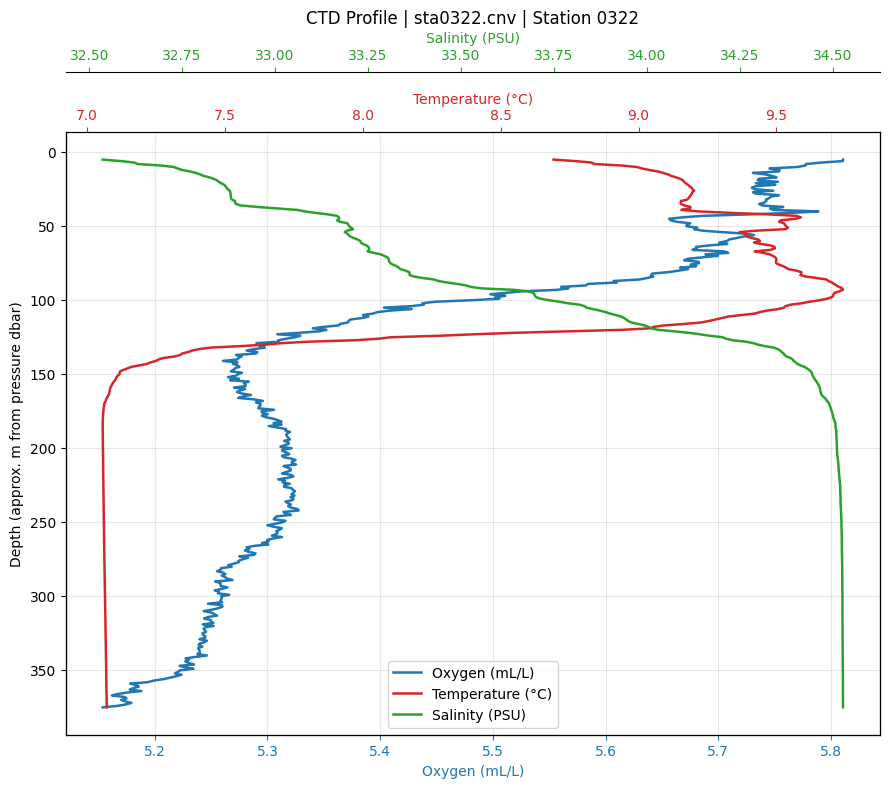

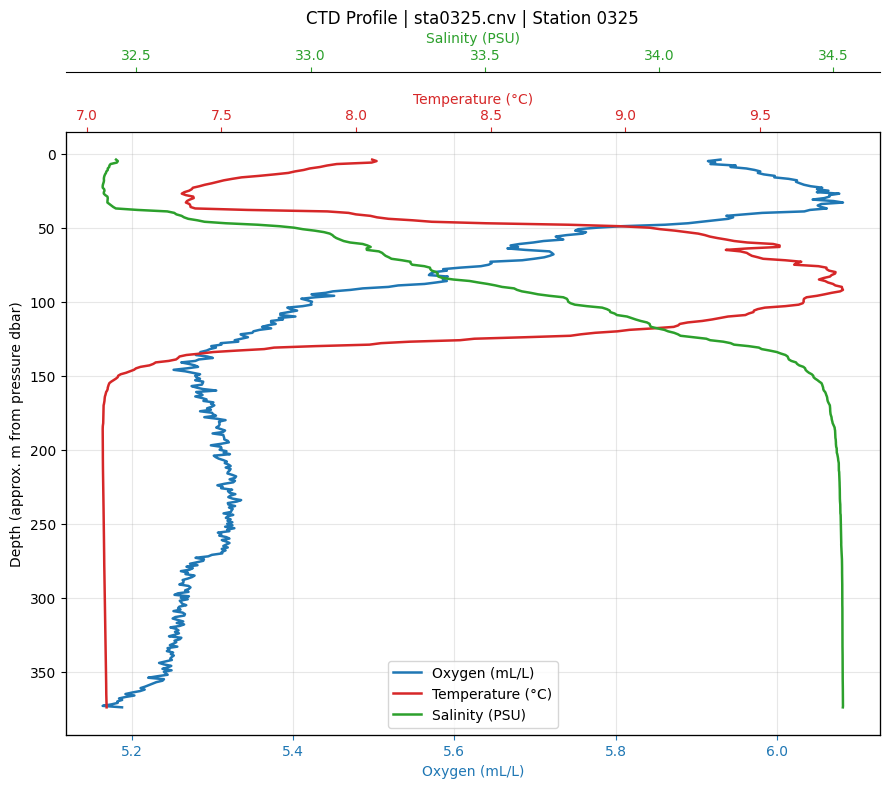

In [10]:
files = ["sta0317.cnv", "sta0318.cnv", "sta0319.cnv", "sta0320.cnv", "sta0321.cnv", "sta0322.cnv", "sta0325.cnv"]
for file in files:
    plot_ctd_profile(file)